In [43]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import seaborn as sns
import pandas as pd
import yfinance as yf

In [34]:
# Initiate ticker
ticker = yf.Ticker('MSFT')
df = ticker.history(period='max')

msft_data = pd.DataFrame(df)
msft_data.head(10)

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
1986-03-13 00:00:00-05:00,0.053847,0.061765,0.053847,0.059125,1031788800,0.0,0.0
1986-03-14 00:00:00-05:00,0.059125,0.062293,0.059125,0.061237,308160000,0.0,0.0
1986-03-17 00:00:00-05:00,0.061237,0.062821,0.061237,0.062293,133171200,0.0,0.0
1986-03-18 00:00:00-05:00,0.062293,0.062821,0.060181,0.060709,67766400,0.0,0.0
1986-03-19 00:00:00-05:00,0.060709,0.061237,0.059125,0.059653,47894400,0.0,0.0
1986-03-20 00:00:00-05:00,0.059653,0.059653,0.057542,0.058070,58435200,0.0,0.0
1986-03-21 00:00:00-05:00,0.058070,0.059125,0.055430,0.056486,59990400,0.0,0.0
1986-03-24 00:00:00-05:00,0.056486,0.056486,0.054374,0.054902,65289600,0.0,0.0
1986-03-25 00:00:00-05:00,0.054902,0.055958,0.054374,0.055958,32083200,0.0,0.0


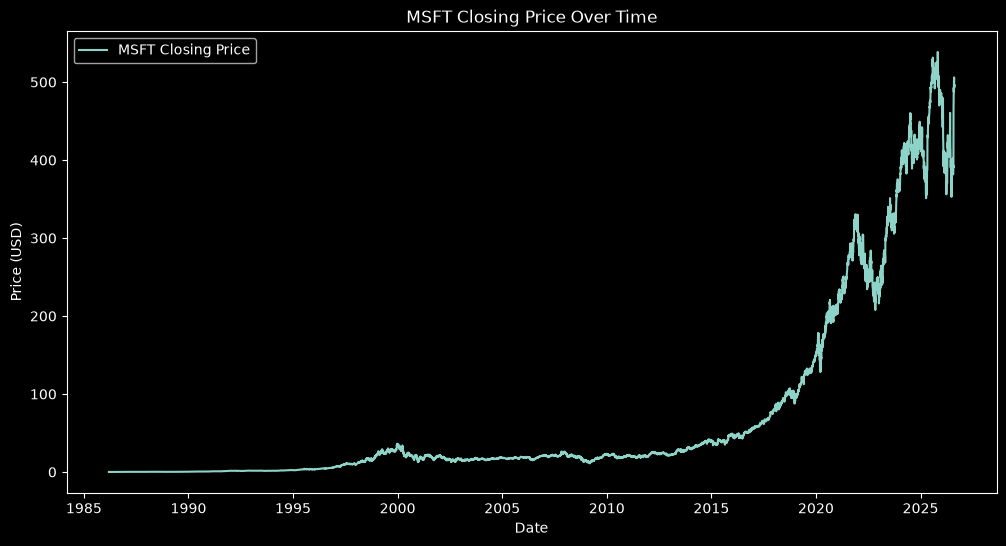

In [35]:
# Plot the closing price over time
plt.figure(figsize=(12, 6))
plt.plot(msft_data['Close'], label='MSFT Closing Price')
plt.title('MSFT Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

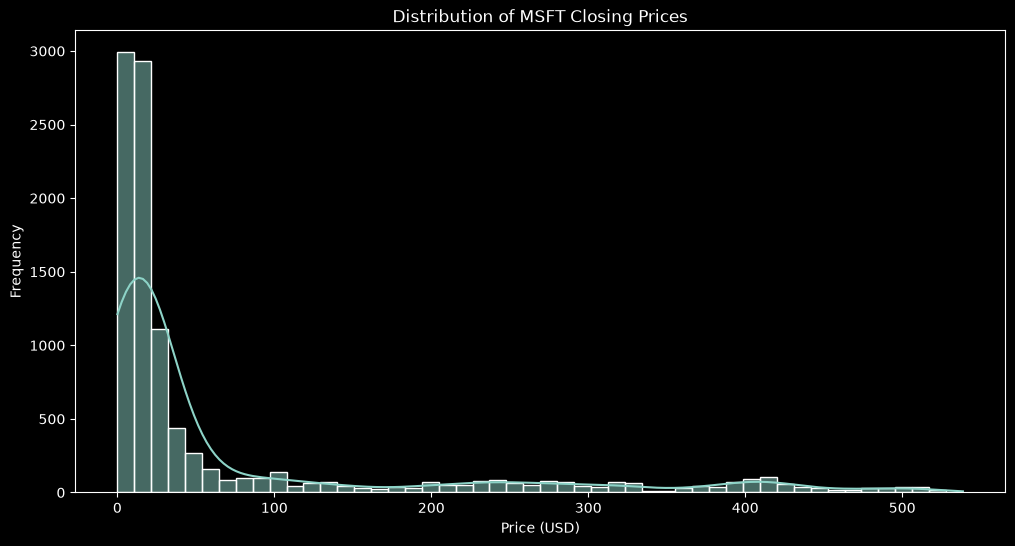

In [41]:
# Plot distribution of the closing prices
plt.figure(figsize=(12, 6))
sns.histplot(msft_data['Close'], bins=50, kde=True)
plt.title('Distribution of MSFT Closing Prices')
plt.xlabel('Price (USD)')
plt.ylabel('Frequency')
plt.show()


In [42]:
# Split the data into training and testing sets
train_data, test_data = train_test_split(msft_data['Close'], test_size=0.2, shuffle=False)
train_data.shape, test_data.shape

((8147,), (2037,))

In [45]:
# Perform Time Series Cross-Validation
tscv = TimeSeriesSplit(n_splits=5)

# Cross-validation loop
for train_index, test_index in tscv.split(train_data):
    cv_train, cv_test = train_data.iloc[train_index], train_data.iloc[test_index]
    print(f'Train size: {len(cv_train)}, Test size: {len(cv_test)}')

# Check for stationarity using Augmented Dickey-Fuller test
result = adfuller(train_data)

print('ADF Statistic:', result[0])
print('p-value:', result[1])

Train size: 1362, Test size: 1357
Train size: 2719, Test size: 1357
Train size: 4076, Test size: 1357
Train size: 5433, Test size: 1357
Train size: 6790, Test size: 1357
ADF Statistic: 4.713577851715722
p-value: 1.0


In [ ]:
# Fit an ARIMA model
model = ARIMA(train_data, order=(5, 1, 0)) # 5 is the number of lag observations, 1 is the degree of differencing, and 0 is the order of the moving average
model_fit = model.fit()

# Summary of the model
print(model_fit.summary())

c:\Users\Troy\Downloads\tchin-european-mc-option-pricing-model\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Troy\Downloads\tchin-european-mc-option-pricing-model\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Troy\Downloads\tchin-european-mc-option-pricing-model\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 8147
Model:                 ARIMA(5, 1, 0)   Log Likelihood               -4248.389
Date:                Sun, 16 Aug 2026   AIC                           8508.778
Time:                        00:48:24   BIC                           8550.809
Sample:                             0   HQIC                          8523.151
                               - 8147                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0649      0.004    -15.300      0.000      -0.073      -0.057
ar.L2         -0.0334      0.005     -6.929      0.000      -0.043      -0.024
ar.L3          0.0150      0.005      3.004      0.0